In [1]:
import pandas as pd
import numpy as np
import os

print("FlightFore - Week 1 EDA")
print("Environment ready!")

FlightFore - Week 1 EDA
Environment ready!


In [2]:
import os

data_path = "../data/raw/flight_ontime_reporting_with_weather"

files = os.listdir(data_path)

print("Number of files:", len(files))
print(files[:20])

Number of files: 30
['ATL.csv', 'AUS.csv', 'BNA.csv', 'BOS.csv', 'BWI.csv', 'CLT.csv', 'DCA.csv', 'DEN.csv', 'DFW.csv', 'DTW.csv', 'EWR.csv', 'FLL.csv', 'IAD.csv', 'IAH.csv', 'JFK.csv', 'LAS.csv', 'LAX.csv', 'LGA.csv', 'MCO.csv', 'MDW.csv']


In [3]:
atl_path = os.path.join(data_path, "ATL.csv")

print("File exists:", os.path.exists(atl_path))

File exists: True


In [4]:
atl = pd.read_csv(atl_path)

print("Shape:", atl.shape)
print("\nColumns:")
print(atl.columns.tolist())

Shape: (1130743, 22)

Columns:
['Time', 'Origin', 'Dest', 'Carrier', 'Cancelled', 'CancellationReason', 'Delayed', 'DepDelayMinutes', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'Temperature', 'Feels_Like_Temperature', 'Altimeter_Pressure', 'Sea_Level_Pressure', 'Visibility', 'Wind_Speed', 'Wind_Gust', 'Precipitation', 'Ice_Accretion_3hr']


In [ ]:
print("Shape:", atl.shape)
print(atl.columns.tolist())
atl.head()

Shape: (1130743, 22)
['Time', 'Origin', 'Dest', 'Carrier', 'Cancelled', 'CancellationReason', 'Delayed', 'DepDelayMinutes', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'Temperature', 'Feels_Like_Temperature', 'Altimeter_Pressure', 'Sea_Level_Pressure', 'Visibility', 'Wind_Speed', 'Wind_Gust', 'Precipitation', 'Ice_Accretion_3hr']


,Time,Origin,Dest,Carrier,Cancelled,CancellationReason,Delayed,DepDelayMinutes,CarrierDelay,WeatherDelay,...,LateAircraftDelay,Temperature,Feels_Like_Temperature,Altimeter_Pressure,Sea_Level_Pressure,Visibility,Wind_Speed,Wind_Gust,Precipitation,Ice_Accretion_3hr
0,2021-01-01 14:00:00,ATL,HOU,Endeavor Air Inc.,False,NaN,True,15.0,2.0,0.0,...,13.0,66.0,66.0,1014.90,1014.6,8046.7,8.06,20.71,1.02,0.0
1,2021-01-01 14:00:00,ATL,HOU,Endeavor Air Inc.,False,NaN,True,15.0,2.0,0.0,...,13.0,66.0,66.0,1014.90,1018.0,16093.4,10.36,24.74,0.51,0.0
2,2021-01-02 14:00:00,ATL,HOU,Endeavor Air Inc.,False,NaN,False,0.0,NaN,NaN,...,NaN,62.0,62.1,1016.26,1015.8,16093.4,5.75,24.74,0.00,0.0
3,2021-01-03 14:00:00,ATL,HOU,Endeavor Air Inc.,False,NaN,True,23.0,23.0,0.0,...,0.0,50.0,50.0,1016.93,1017.2,16093.4,14.96,20.71,0.00,0.0
4,2021-01-04 14:00:00,ATL,HOU,Endeavor Air Inc.,False,NaN,False,0.0,NaN,NaN,...,NaN,56.0,55.9,1016.93,1017.0,16093.4,6.90,24.74,0.00,0.0


In [5]:
atl.info()
atl.isnull().sum()
atl["Cancelled"].value_counts()
atl["Cancelled"].value_counts(normalize=True) * 100
atl["DepDelayMinutes"].describe()

<class 'pandas.DataFrame'>
RangeIndex: 1130743 entries, 0 to 1130742
Data columns (total 22 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Time                    1130743 non-null  str    
 1   Origin                  1130743 non-null  str    
 2   Dest                    1130743 non-null  str    
 3   Carrier                 1130743 non-null  str    
 4   Cancelled               1130743 non-null  bool   
 5   CancellationReason      12772 non-null    str    
 6   Delayed                 1130743 non-null  bool   
 7   DepDelayMinutes         1118248 non-null  float64
 8   CarrierDelay            206887 non-null   float64
 9   WeatherDelay            206887 non-null   float64
 10  NASDelay                206887 non-null   float64
 11  SecurityDelay           206887 non-null   float64
 12  LateAircraftDelay       206887 non-null   float64
 13  Temperature             1130743 non-null  float64
 14  Feels_Like_Te

count    1.118248e+06
mean     1.262744e+01
std      4.216015e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      8.000000e+00
max      3.221000e+03
Name: DepDelayMinutes, dtype: float64

In [6]:
print("Cancellation counts:")
print(atl["Cancelled"].value_counts())

print("\nCancellation percentages:")
print(atl["Cancelled"].value_counts(normalize=True) * 100)

print("Delayed counts:")
print(atl["Delayed"].value_counts())

print("\nOrigin airports:")
print(atl["Origin"].value_counts())

print("\nDestination airports:")
print(atl["Dest"].nunique())

print("\nCarriers:")
print(atl["Carrier"].nunique())

print(atl["Time"].min())
print(atl["Time"].max())

Cancellation counts:
Cancelled
False    1117971
True       12772
Name: count, dtype: int64

Cancellation percentages:
Cancelled
False    98.870477
True      1.129523
Name: proportion, dtype: float64
Delayed counts:
Delayed
False    714549
True     416194
Name: count, dtype: int64

Origin airports:
Origin
ATL    1130743
Name: count, dtype: int64

Destination airports:
162

Carriers:
14
2021-01-01 06:00:00
2023-12-30 23:00:00


## Creating copy of the dataset

In [7]:
eda = atl.copy()

In [8]:
eda["Time"] = pd.to_datetime(eda["Time"])
eda["Hour"] = eda["Time"].dt.hour
eda["DayOfWeek"] = eda["Time"].dt.dayofweek
eda["Month"] = eda["Time"].dt.month
eda[["Time", "Hour", "DayOfWeek", "Month"]].head()

,Time,Hour,DayOfWeek,Month
0,2021-01-01 14:00:00,14,4,1
1,2021-01-01 14:00:00,14,4,1
2,2021-01-02 14:00:00,14,5,1
3,2021-01-03 14:00:00,14,6,1
4,2021-01-04 14:00:00,14,0,1


## Delay Distribution

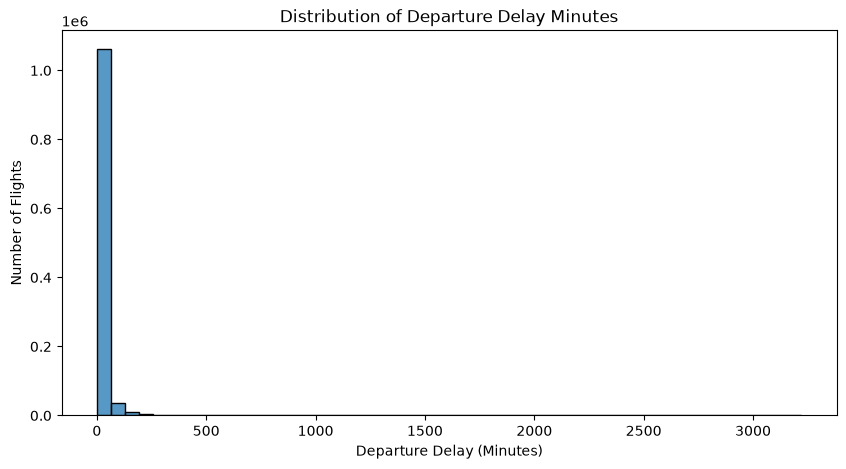

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    eda["DepDelayMinutes"].dropna(),
    bins=50
)

plt.title("Distribution of Departure Delay Minutes")
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Number of Flights")

plt.show()

## Cancelation Distribution

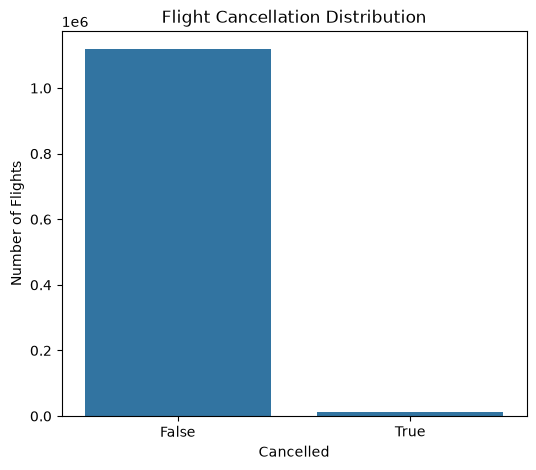

In [10]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=eda,
    x="Cancelled"
)

plt.title("Flight Cancellation Distribution")
plt.xlabel("Cancelled")
plt.ylabel("Number of Flights")

plt.show()

## Delay by hour

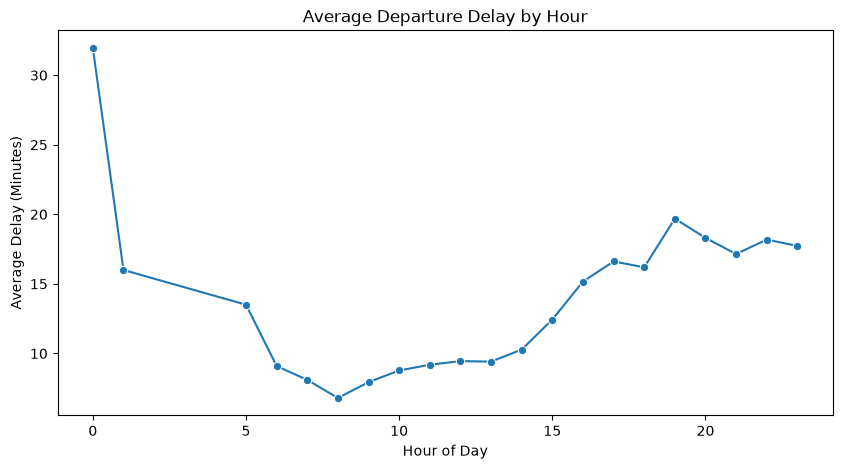

In [11]:
hour_delay = (
    eda.groupby("Hour")["DepDelayMinutes"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_delay,
    x="Hour",
    y="DepDelayMinutes",
    marker="o"
)

plt.title("Average Departure Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (Minutes)")

plt.show()

## Cancelation rate by hour

In [16]:
hour_analysis = (
    eda.groupby("Hour")
    .agg(
        Total_Flights=("Cancelled", "size"),
        Cancelled_Flights=("Cancelled", "sum"),
        Cancellation_Rate=("Cancelled", "mean")
    )
    .reset_index()
)

hour_analysis["Cancellation_Rate"] *= 100

print(hour_analysis.to_string(index=False))

 Hour  Total_Flights  Cancelled_Flights  Cancellation_Rate
    0           3901                106           2.717252
    1              3                  2          66.666667
    5           1915                 32           1.671018
    6          20299                437           2.152815
    7          43643                668           1.530601
    8          72666                829           1.140836
    9          86095                862           1.001220
   10         105131               1099           1.045362
   11          78521                708           0.901670
   12          52967                518           0.977967
   13          49633                509           1.025527
   14          70190                567           0.807807
   15          70594                614           0.869762
   16          65086                713           1.095474
   17          57386                656           1.143136
   18          57603                717           1.2447

## Weather vs delay

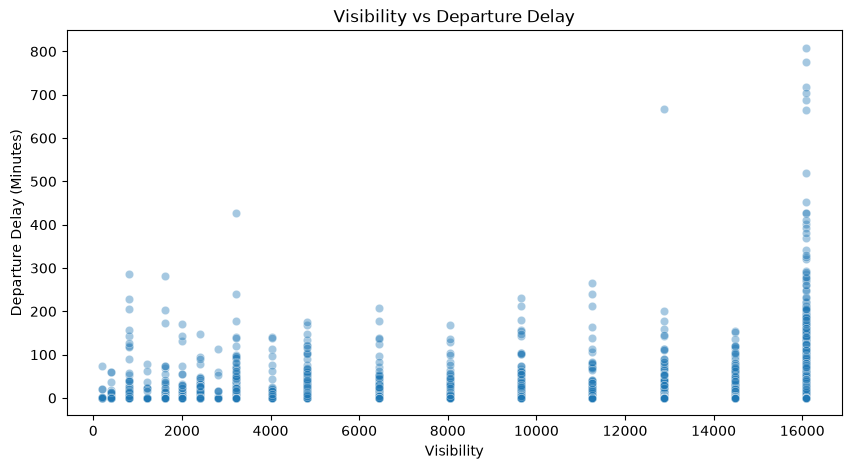

In [14]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=eda.sample(min(10000, len(eda))),
    x="Visibility",
    y="DepDelayMinutes",
    alpha=0.4
)

plt.title("Visibility vs Departure Delay")
plt.xlabel("Visibility")
plt.ylabel("Departure Delay (Minutes)")

plt.show()

## Correlation between numerical variables

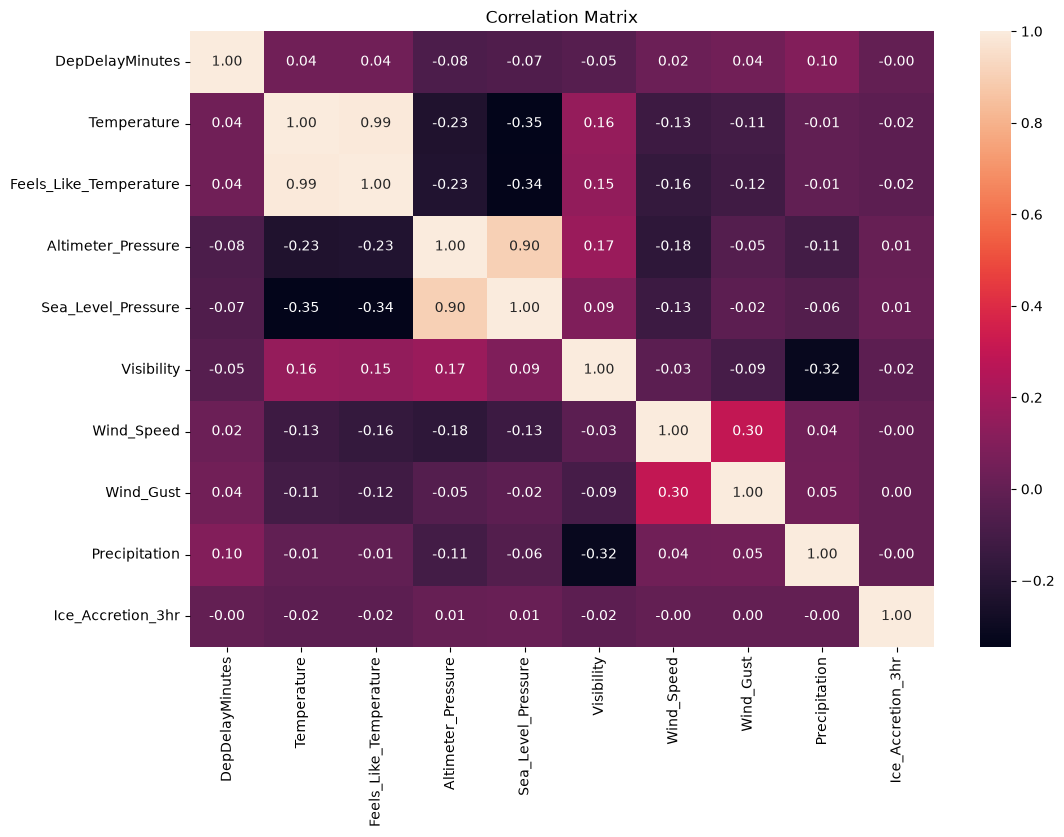

In [15]:
numeric_columns = [
    "DepDelayMinutes",
    "Temperature",
    "Feels_Like_Temperature",
    "Altimeter_Pressure",
    "Sea_Level_Pressure",
    "Visibility",
    "Wind_Speed",
    "Wind_Gust",
    "Precipitation",
    "Ice_Accretion_3hr"
]

correlation = eda[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()